cuda
적용된 폰트: ['Malgun Gothic']


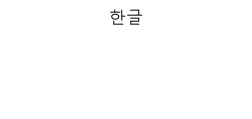

In [ ]:
# 09/10
import os, time, copy
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from PIL import Image
from tqdm.auto import tqdm
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, random_split, Subset, DataLoader
from torchvision import datasets, transforms

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import platform
from matplotlib import font_manager

system = platform.system()
if system == 'Windows':
    # Windows는 맑은 고딕이 기본 내장되어 있어 설치 없이 바로 사용 가능
    plt.rc('font', family='Malgun Gothic')
elif system == 'Darwin':
    # macOS 기본 내장 한글 폰트
    plt.rc('font', family='AppleGothic')
else:
    # Colab 등 Linux: 위 셀에서 설치한 나눔고딕을 등록
    font_dir = '/usr/share/fonts/truetype/nanum'
    font_files = font_manager.findSystemFonts(fontpaths=font_dir)
    for fpath in font_files:
        font_manager.fontManager.addfont(fpath)
    plt.rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

# 설정한 폰트가 실제로 잡혔는지 확인
print('적용된 폰트:', plt.rcParams['font.family'])
plt.figure(figsize=(3,1))
plt.title('한글')
plt.axis('off')
plt.show()

In [8]:
sentence = ['The', 'cat', 'sat', 'on', 'the', 'mat']

attention_scores = {'The': 0.1,
                    'cat': 1.0,
                    'sat': 0.8,
                    'on': 0.3,
                    'the': 0.1,
                    'mat': 0.6}

In [9]:
word_vectors = {'The': [0.1, 0.2, 0.3],
                'cat': [0.5, 0.8, 0.2],
                'sat': [0.7, 0.1, 0.9],
                'on': [0.2, 0.6, 0.3],
                'the': [0.1, 0.2, 0.3],
                'mat': [0.8, 0.3, 0.5]}

new_vector = []

for dim in range(3):
    weighted_sum = (0.1 * word_vectors['The'][dim] +
                    1.0 * word_vectors['cat'][dim] +
                    0.8 * word_vectors['sat'][dim] +
                    0.3 * word_vectors['on'][dim] +
                    0.1 * word_vectors['the'][dim] +
                    0.6 * word_vectors['mat'][dim])
    new_vector.append(weighted_sum)

print(word_vectors['cat'])
print(new_vector)

[0.5, 0.8, 0.2]
[1.6199999999999999, 1.28, 1.37]


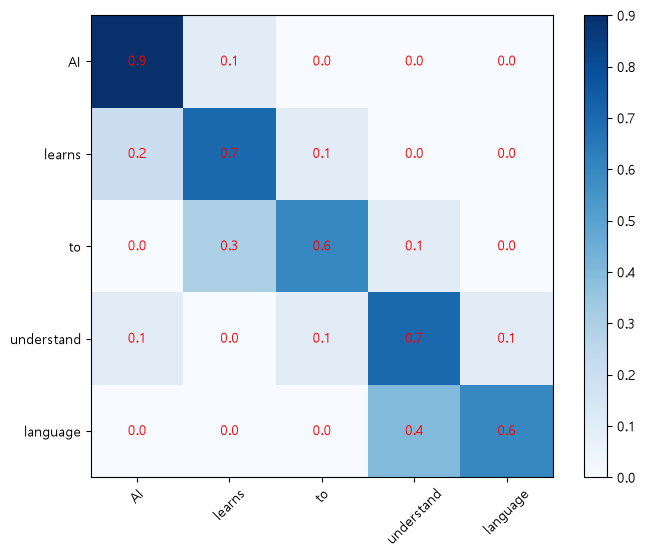

In [10]:
import matplotlib.pyplot as plt
import numpy as np

words = ['AI', 'learns', 'to', 'understand', 'language']

attention_matrix = np.array([[0.9, 0.1, 0.0, 0.0, 0.0],
                             [0.2, 0.7, 0.1, 0.0, 0.0],
                             [0.0, 0.3, 0.6, 0.1, 0.0],
                             [0.1, 0.0, 0.1, 0.7, 0.1],
                             [0.0, 0.0, 0.0, 0.4, 0.6]])

plt.figure(figsize=(8,6))
plt.imshow(attention_matrix, cmap='Blues')
plt.xticks(range(len(words)), words, rotation=45)
plt.yticks(range(len(words)), words)
plt.colorbar()

for i in range(len(words)):
    for j in range(len(words)):
        plt.text(j, i, f'{attention_matrix[i, j]:.1f}',
                 ha='center',
                 va='center',
                 color='red')
plt.show()

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np

class SelfAttentionExplainer:
    def __init__(self, d_model=512):
        self.d_model = d_model
    def step_by_step_attention(self, sentence):
        words = sentence.split()
        vocab_size = len(words)
        embeddings = torch.randn(vocab_size, self.d_model)
        for i, word in enumerate(words):
            print(word, embeddings[i][:5].tolist())
        W_q = torch.randn(self.d_model, self.d_model)
        W_k = torch.randn(self.d_model, self.d_model)
        W_v = torch.randn(self.d_model, self.d_model)

        Q = embeddings @ W_q
        K = embeddings @ W_k
        V = embeddings @ W_v

        print(Q.shape)
        print(K.shape)
        print(V.shape)

        scores = Q @ K.T / np.sqrt(self.d_model)
        print(scores.shape)

        attention_weights = F.softmax(scores, dim = 1)

        plt.figure(figsize=(10,8))
        plt.imshow(attention_weights.detach().numpy(), cmap='Blues')
        plt.xticks(range(len(words)), words, rotation=45)
        plt.yticks(range(len(words)), words)
        plt.colorbar()

        for i in range(len(words)):
            for j in range(len(words)):
                plt.text(j, i, f'{attention_weights[i, j]:.2f}',
                         ha='center',
                         va='center',
                         color='red' if attention_weights[i,j] > 0.3 else 'black')
        plt.tight_layout()
        plt.show()

        output = attention_weights @ V
        print(output.shape)

        for i, word in enumerate(words):
            top_attention = torch.argmax(attention_weights[i])
            top_word = words[top_attention]
            top_score = attention_weights[i, top_attention].item()
        return output, attention_weights

In [12]:
def run_attention_demo():
    explainer = SelfAttentionExplainer()
    sentences = ['The cat sat on the mat',
                 'AI learns to understand language',
                 'Transformer models revolutionized NLP']

    for sentence in sentences:
        output, weights = explainer.step_by_step_attention(sentence)

In [13]:
class PracticalAttentionExample:
    def __init__(self):
        self.multihead_attn = nn.MultiheadAttention(embed_dim=512,
                                                    num_heads=8,
                                                    batch_first=True)
    def text_classification_with_attention(self):
        batch_size, seq_len, embed_dim = 2, 10, 512
        text_embeddings = torch.randn(batch_size, seq_len, embed_dim)
        attn_output, attn_weights = self.multihead_attn(text_embeddings,
                                                        text_embeddings,
                                                        text_embeddings)
        print(text_embeddings.shape)
        print(attn_output.shape)
        print(attn_weights.shape)

        classifier = nn.Sequential(nn.Linear(embed_dim, 256),
                                   nn.ReLU(),
                                   nn.Dropout(0.1),
                                   nn.Linear(256, 3))

        pooled = attn_output.mean(dim=1)
        predictions = classifier(pooled)
        print(predictions.shape)
        return predictions

The [1.9269152879714966, 1.4872840642929077, 0.9007171988487244, -2.1055209636688232, 0.6784183979034424]
cat [-1.363769769668579, 0.1929578185081482, -0.6103342771530151, 0.16323445737361908, 1.51017165184021]
sat [-1.2247875928878784, 0.962885856628418, -1.5785412788391113, 0.6715953946113586, -0.060151856392621994]
on [-0.8496796488761902, -0.6987038254737854, -0.20516234636306763, -0.7811664342880249, 0.6872723698616028]
the [-0.6002296209335327, -0.05797451362013817, 0.2974875271320343, 1.6327744722366333, -1.4954025745391846]
mat [-0.6744462847709656, -1.8892930746078491, -1.842443585395813, 0.13227719068527222, -0.792870283126831]
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 512])
torch.Size([6, 6])


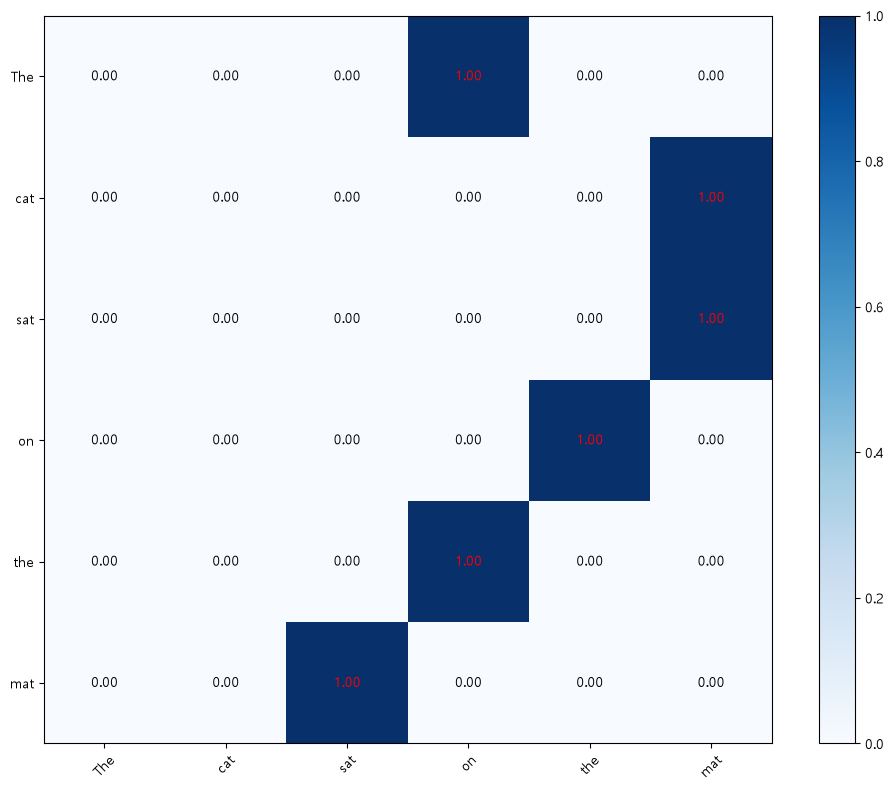

torch.Size([6, 512])
AI [1.483606219291687, -0.8839794397354126, 0.02507997490465641, -0.3091040849685669, 0.2944410741329193]
learns [0.10223610699176788, -0.24510915577411652, 0.6841301918029785, -0.04175140708684921, 1.4119594097137451]
to [1.9694931507110596, 0.47024524211883545, -0.08622202277183533, 0.9760724902153015, 1.89774489402771]
understand [-0.5637573599815369, 1.1826218366622925, -0.6230647563934326, -0.0666445642709732, 0.6261868476867676]
language [0.8988561034202576, -0.6024367809295654, 1.5994008779525757, 0.04987981915473938, -0.4057415723800659]
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 512])
torch.Size([5, 5])


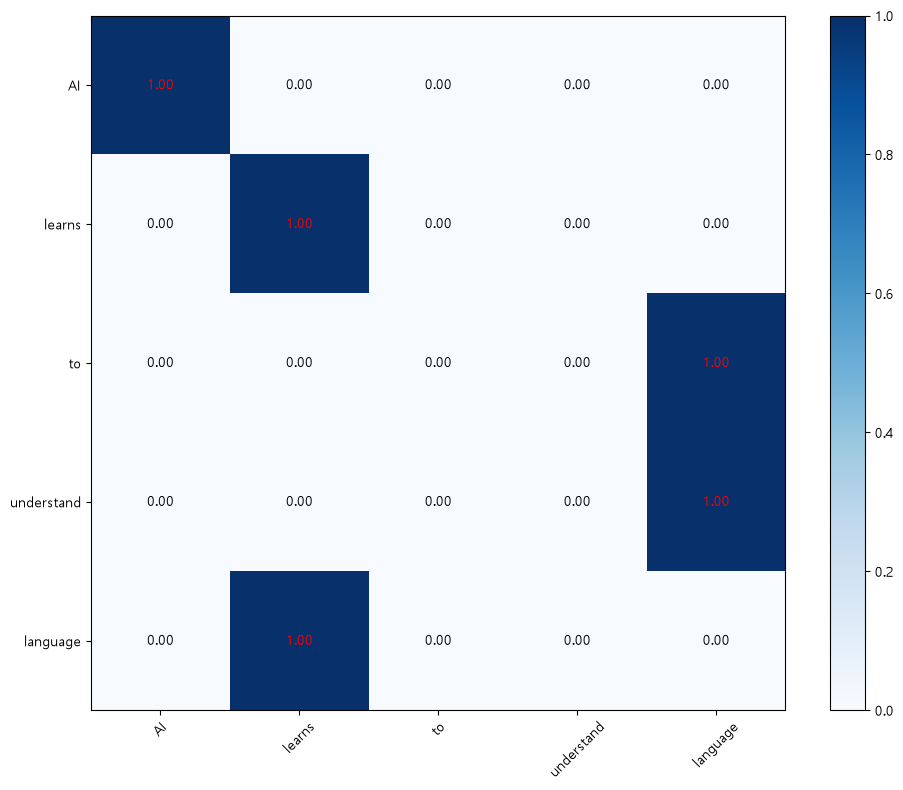

torch.Size([5, 512])
Transformer [0.34485381841659546, 1.521615982055664, 0.5531842112541199, 0.0868353396654129, -0.1800006777048111]
models [-0.3342894911766052, -1.4037833213806152, 0.5990857481956482, 0.18950118124485016, -0.012440907768905163]
revolutionized [1.4701626300811768, 0.49768319725990295, 0.20461615920066833, 0.1481499820947647, 0.456330269575119]
NLP [-1.4160321950912476, 0.09568687528371811, -0.3575122654438019, 0.3689078092575073, -0.9453819394111633]
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 512])
torch.Size([4, 4])


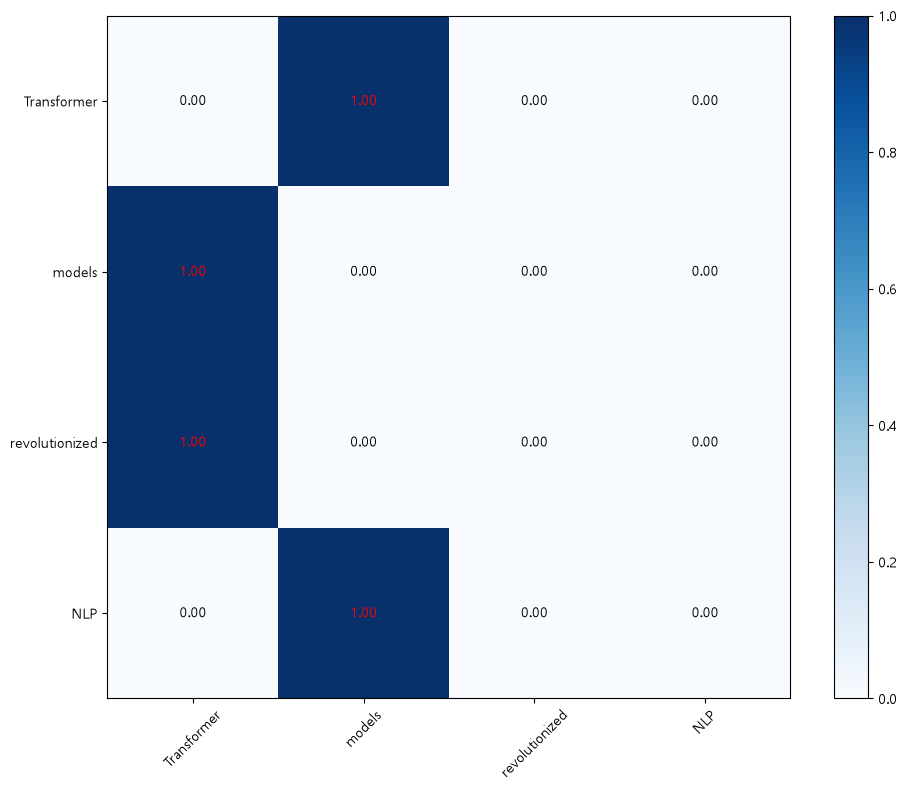

torch.Size([4, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 512])
torch.Size([2, 10, 10])
torch.Size([2, 3])


tensor([[-0.0537,  0.0489,  0.0348],
        [-0.0314,  0.0194, -0.0050]], grad_fn=<AddmmBackward0>)

In [14]:
run_attention_demo()

practical = PracticalAttentionExample()
practical.text_classification_with_attention()

In [17]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertForSequenceClassification.from_pretrained('bert-base-uncased',
                                                      num_labels=2)

sentence = 'This movie was fantastic!'
inputs = tokenizer(sentence,
                   return_tensors='pt',
                   truncation=True,
                   padding=True)

outputs = model(**inputs)
logits = outputs.logits
predicted_class = torch.argmax(logits, dim=1)
print(predicted_class.item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


0


In [19]:
from transformers import BertTokenizer, BertForSequenceClassification
import torch
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

sentences = ['I love this movie',
             'I hate this movie',
             'It was okay',
             'Fantastic film',
             'Terrible experience']
labels = torch.tensor([1, 0, 1, 1, 0])

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
encoded_inputs = tokenizer(sentences,
                           padding=True,
                           truncation=True,
                           return_tensors='pt')
labels_tensor = torch.tensor(labels)
dataset = TensorDataset(encoded_inputs['input_ids'],
                        labels_tensor)
train_loader = DataLoader(dataset,
                          batch_size=2,
                          shuffle=True)
model_fe = BertForSequenceClassification.from_pretrained('bert-base-uncased',
                                                         num_labels=2)
for param in model_fe.bert.parameters():
    param.requires_grad=False
optimizer_fe = optim.Adam(model_fe.parameters(), lr=2e-5)
model_ft = BertForSequenceClassification.from_pretrained('bert-base-uncased',
                                                         num_labels=2)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=2e-5)

def train_model(model, optimizer, epochs=3):
    model.train()
    for epoch in range(epochs):
        for input_ids, label in train_loader:
            optimizer.zero_grad()
            outputs = model(input_ids, labels=label)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
train_model(model_fe, optimizer_fe)
train_model(model_ft, optimizer_ft)

C:\Users\KDS10\AppData\Local\Temp\ipykernel_7688\867822596.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  labels_tensor = torch.tensor(labels)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [21]:
import torch
import torch.nn as nn
import torchvision.models as models
from torchvision import transforms
from PIL import Image

resnet18 = models.resnet18(pretrained=True)
num_ftrs = resnet18.fc.in_features
resnet18.fc = nn.Linear(num_ftrs, 10)

resnet18.eval()

transform = transforms.Compose([transforms.Resize((224,224)),
                               transforms.ToTensor(),
                               transforms.Normalize(mean=[0.485,0.456,0.406],
                                                    std=[0.229,0.224,0.225])])
img = Image.open('example.jpg').convert('RGB')
img_t = transform(img)
img_t = img_t.unsqueeze(0)
outputs = resnet18(img_t)
_, predicted = torch.max(outputs, 1)
print(predicted.item())

0
